In [1]:
import yfinance as yf
import pandas as pd

ticker = "GLD"
gold_data = yf.download(ticker, start="2000-01-01", end=None, progress=False, auto_adjust=False, actions=True)
gold_data


Price,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
Ticker,GLD,GLD,GLD,GLD,GLD,GLD,GLD,GLD,GLD
Date,,,,,,,,,
2004-11-18,44.380001,0.0,44.380001,0.0,44.490002,44.070000,44.430000,0.0,5992000
2004-11-19,44.779999,0.0,44.779999,0.0,44.919998,44.470001,44.490002,0.0,11655300
2004-11-22,44.950001,0.0,44.950001,0.0,44.970001,44.740002,44.750000,0.0,11996000
2004-11-23,44.750000,0.0,44.750000,0.0,44.919998,44.720001,44.880001,0.0,3169200
2004-11-24,45.049999,0.0,45.049999,0.0,45.049999,44.790001,44.930000,0.0,6105100
...,...,...,...,...,...,...,...,...,...
2025-04-14,296.230011,0.0,296.230011,0.0,296.579987,294.529999,295.540009,0.0,12427600
2025-04-15,297.779999,0.0,297.779999,0.0,298.019989,296.089996,296.929993,0.0,7924100


In [2]:
gold_data.reset_index(inplace=True)
gold_data.columns = [col[0] for col in gold_data.columns]

In [3]:
gold_data["Date"] = pd.to_datetime(gold_data["Date"])

In [4]:
finbert_score = pd.read_csv("Final_sentiment_score.csv")
finbert_score = finbert_score[["Date", "Positive", "Neutral", "Negative"]]
finbert_score

,Date,Positive,Neutral,Negative
0,2000-02-15,0.398276,0.585515,0.016209
1,2000-02-17,0.077722,0.095735,0.826543
2,2000-03-24,0.180700,0.287722,0.531578
3,2000-04-27,0.393267,0.346374,0.260358
4,2000-05-04,0.337279,0.255016,0.407705
...,...,...,...,...
3667,2019-01-25,0.786646,0.120372,0.092982
3668,2019-01-28,0.749922,0.169181,0.080897
3669,2019-01-30,0.790114,0.135270,0.074616
3670,2019-01-31,0.128171,0.481111,0.390717


In [5]:
finbert_score["Date"] = pd.to_datetime(finbert_score["Date"])

In [6]:
merged_df = pd.merge(
    finbert_score, gold_data, left_on="Date", right_on="Date", how="inner"
)

In [7]:
merged_df

,Date,Positive,Neutral,Negative,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
0,2004-11-18,0.173866,0.072946,0.753188,44.380001,0.0,44.380001,0.0,44.490002,44.070000,44.430000,0.0,5992000
1,2004-11-19,0.803936,0.118606,0.077459,44.779999,0.0,44.779999,0.0,44.919998,44.470001,44.490002,0.0,11655300
2,2004-11-22,0.429147,0.489576,0.081276,44.950001,0.0,44.950001,0.0,44.970001,44.740002,44.750000,0.0,11996000
3,2004-11-23,0.075817,0.047289,0.876894,44.750000,0.0,44.750000,0.0,44.919998,44.720001,44.880001,0.0,3169200
4,2004-11-24,0.930440,0.031681,0.037879,45.049999,0.0,45.049999,0.0,45.049999,44.790001,44.930000,0.0,6105100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2019-01-25,0.786646,0.120372,0.092982,122.860001,0.0,122.860001,0.0,122.910004,122.019997,122.019997,0.0,11103300
2915,2019-01-28,0.749922,0.169181,0.080897,123.290001,0.0,123.290001,0.0,123.290001,122.720001,122.750000,0.0,8522200
2916,2019-01-30,0.790114,0.135270,0.074616,124.690002,0.0,124.690002,0.0,125.070000,123.699997,123.910004,0.0,12104000
2917,2019-01-31,0.128171,0.481111,0.390717,124.750000,0.0,124.750000,0.0,125.230003,124.620003,125.180000,0.0,10209500


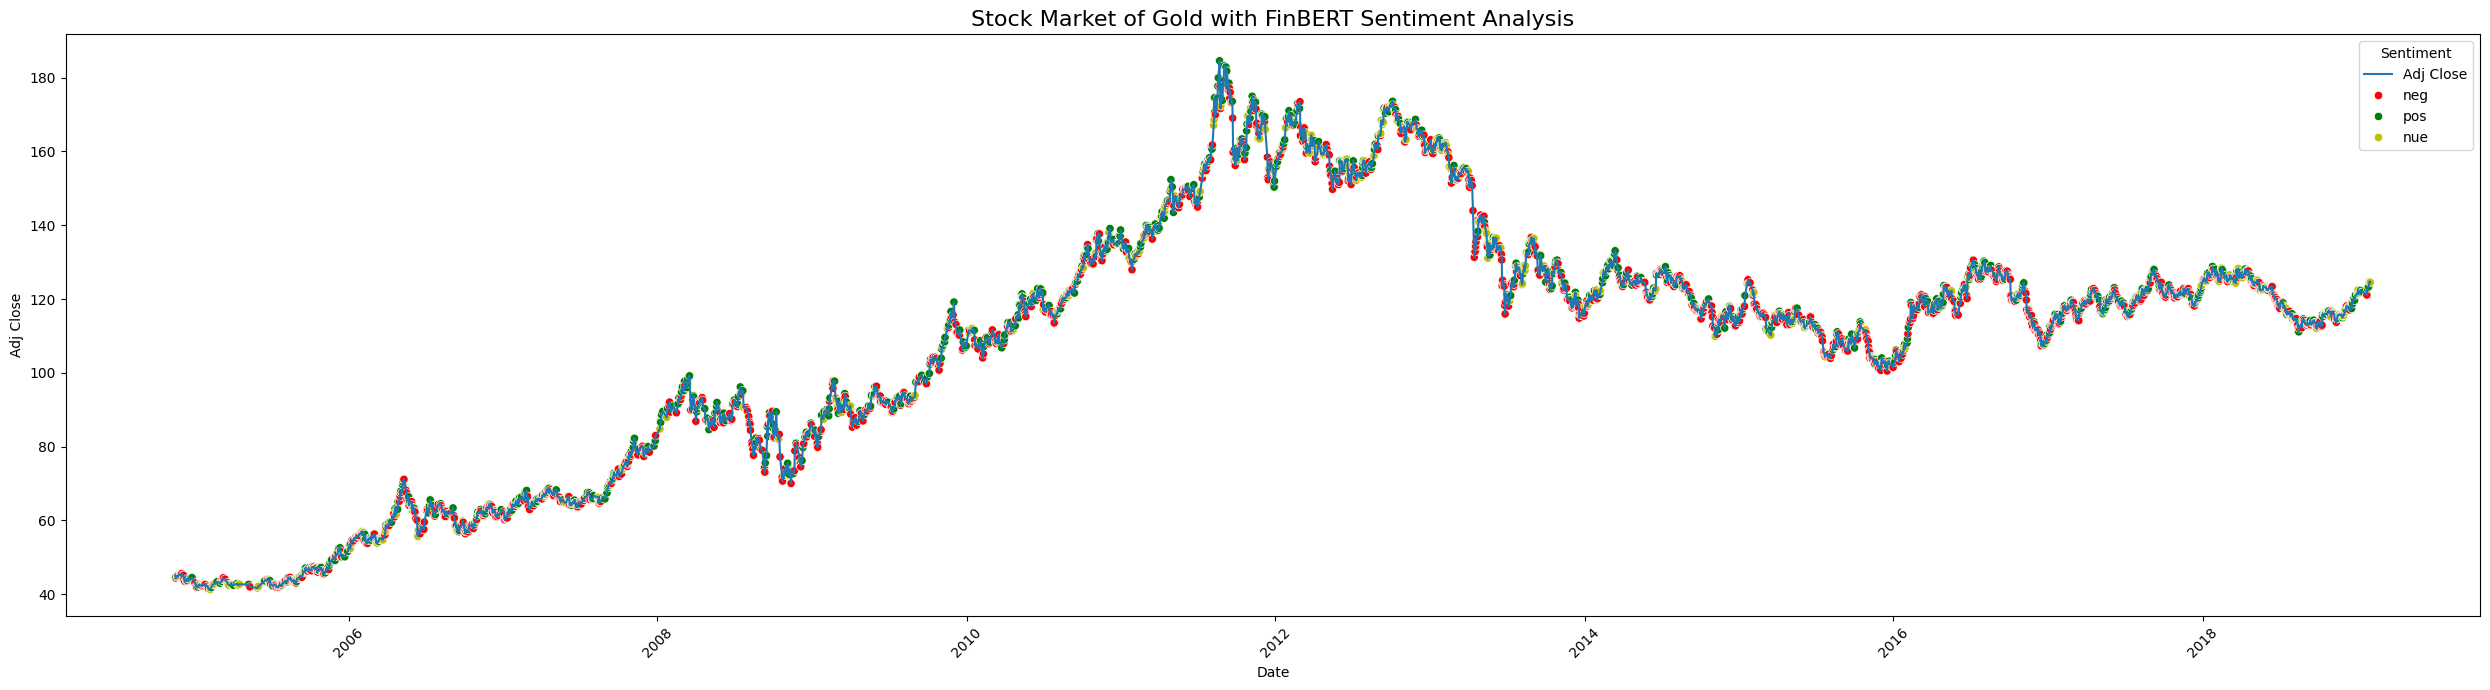

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(25, 7))

sns.lineplot(x=merged_df["Date"], y=merged_df["Adj Close"], label="Adj Close")

def get_sentiment(row):
    sentiments = {'pos': row['Positive'], 'nue': row['Neutral'], 'neg': row['Negative']}
    return max(sentiments, key=sentiments.get)

merged_df['sentiment_analysis'] = merged_df.apply(get_sentiment, axis=1)

sns.scatterplot(x=merged_df["Date"], y=merged_df["Adj Close"], hue=merged_df['sentiment_analysis'], palette={'pos': 'g', 'nue': 'y', 'neg': 'r'})
plt.xticks(rotation=45)
plt.title("Stock Market of Gold with FinBERT Sentiment Analysis", fontsize=16)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()


In [9]:
merged_df.columns

Index(['Date', 'Positive', 'Neutral', 'Negative', 'Adj Close', 'Capital Gains',
       'Close', 'Dividends', 'High', 'Low', 'Open', 'Stock Splits', 'Volume',
       'sentiment_analysis'],
      dtype='object')

In [10]:
merged_df['sentiment_score'] = merged_df['Positive'] - merged_df['Negative']


In [11]:
cols = ['Open',
    'High', 'Low',
    'Close',
    'Volume',
    'Adj Close',
    'sentiment_score',]

In [12]:
df_for_training = merged_df[cols].astype(float)
df_for_training.index=merged_df['Date']
df_for_training

,Open,High,Low,Close,Volume,Adj Close,sentiment_score
Date,,,,,,,
2004-11-18,44.430000,44.490002,44.070000,44.380001,5992000.0,44.380001,-0.579322
2004-11-19,44.490002,44.919998,44.470001,44.779999,11655300.0,44.779999,0.726477
2004-11-22,44.750000,44.970001,44.740002,44.950001,11996000.0,44.950001,0.347871
2004-11-23,44.880001,44.919998,44.720001,44.750000,3169200.0,44.750000,-0.801077
2004-11-24,44.930000,45.049999,44.790001,45.049999,6105100.0,45.049999,0.892562
...,...,...,...,...,...,...,...
2019-01-25,122.019997,122.910004,122.019997,122.860001,11103300.0,122.860001,0.693664
2019-01-28,122.750000,123.290001,122.720001,123.290001,8522200.0,123.290001,0.669025
2019-01-30,123.910004,125.070000,123.699997,124.690002,12104000.0,124.690002,0.715498


In [13]:
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()
scaler = scaler.fit(df_for_training)
df_for_training_scaled = scaler.transform(df_for_training)

scaler_for_inference = MinMaxScaler()
scaler_for_inference.fit_transform(df_for_training.loc[:,['Open','Adj Close']])

df_for_training_scaled

array([[0.02259573, 0.02139149, 0.02141085, ..., 0.05925445, 0.02176797,
        0.20439762],
       [0.02301418, 0.02436827, 0.02424673, ..., 0.11992625, 0.02455871,
        0.89116646],
       [0.0248274 , 0.02471443, 0.02616095, ..., 0.12357622, 0.0257448 ,
        0.69204351],
       ...,
       [0.57688823, 0.57923154, 0.58596238, ..., 0.12473324, 0.58208334,
        0.88539197],
       [0.58574517, 0.58033921, 0.59248493, ..., 0.10443717, 0.58250194,
        0.37100216],
       [0.58372271, 0.5790931 , 0.59071251, ..., 0.12882031, 0.58075771,
        0.5325654 ]])

In [14]:
import numpy as np

trainX = []
trainY = []

n_future = 1  
n_past = 5  

for i in range(n_past, len(df_for_training_scaled) - n_future +1):
    trainX.append(df_for_training_scaled[i - n_past:i, 0:df_for_training.shape[1]])
    trainY.append(df_for_training_scaled[i + n_future - 1:i + n_future,[0,-2]])

trainX, trainY = np.array(trainX), np.array(trainY)

print('TrainX shape = {}.'.format(trainX.shape))
print('TrainY shape = {}.'.format(trainY.shape))

TrainX shape = (2914, 5, 7).
TrainY shape = (2914, 1, 2).


In [15]:
from sklearn.model_selection import train_test_split

# possible issue is we pick up random dates

X_train_lstm_without_sentiment, X_test_lstm_without_sentiment, y_train_lstm_without_sentiment, y_test_lstm_without_sentiment = train_test_split(trainX[:,:,:-1], trainY, test_size=0.2, shuffle=False)

X_train_lstm_sentiment, X_test_lstm_sentiment, y_train_lstm_sentiment, y_test_lstm_sentiment = train_test_split(trainX, trainY, test_size=0.2, shuffle=False)

X_train_lstm_without_sentiment.shape,X_train_lstm_sentiment.shape

((2331, 5, 6), (2331, 5, 7))

In [16]:
# validation
X_train_lstm_without_sentiment, X_val_lstm_without_sentiment, y_train_lstm_without_sentiment, y_val_lstm_without_sentiment = train_test_split(X_train_lstm_without_sentiment, y_train_lstm_without_sentiment, test_size=0.1, shuffle=False)

X_train_lstm_sentiment, X_val_lstm_sentiment, y_train_lstm_sentiment, y_val_lstm_sentiment = train_test_split(X_train_lstm_sentiment, y_train_lstm_sentiment, test_size=0.1, shuffle=False)

X_train_lstm_without_sentiment.shape,X_train_lstm_sentiment.shape

((2097, 5, 6), (2097, 5, 7))

In [18]:
import tensorflow as tf
from keras.callbacks import ModelCheckpoint
from keras.models import Sequential
from keras.layers import LSTM,Conv1D,Conv2D,MaxPooling2D,MaxPooling1D,Flatten, Bidirectional, LSTM
from keras.layers import Dense, Dropout
import pandas as pd
from keras.optimizers import Adam
from tensorflow import keras
seed=42


def build_model(input_shape):
    tf.random.set_seed(seed)
    cnn_lstm_model = Sequential()

    cnn_lstm_model.add(Conv1D(filters=128, kernel_size=2, strides=1, padding='valid', input_shape=input_shape))
    cnn_lstm_model.add(MaxPooling1D(pool_size=2, strides=2))

    cnn_lstm_model.add(Conv1D(filters=64, kernel_size=2, strides=1, padding='valid'))
    cnn_lstm_model.add(MaxPooling1D(pool_size=1, strides=2))
    # cnn_lstm_model.add(MaxPooling1D(pool_size=1, strides=2))

    cnn_lstm_model.add(Bidirectional(LSTM(256, return_sequences=True)))
    cnn_lstm_model.add(Dropout(0.2))
    cnn_lstm_model.add(Bidirectional(LSTM(256, return_sequences=True)))
    cnn_lstm_model.add(Dropout(0.2))

    cnn_lstm_model.add(Dense(32, activation='relu'))


    cnn_lstm_model.add(Dense(trainY.shape[2], activation='relu'))

    # cnn_lstm_model.build(input_shape=(trainX.shape[0], trainX.shape[1], trainX.shape[2]))

    cnn_lstm_model.compile(optimizer='adam', loss='mse')
    cnn_lstm_model.summary()
    return cnn_lstm_model

In [19]:
cnn_lstm_model_without_sentiment=build_model((X_train_lstm_without_sentiment.shape[1],X_train_lstm_without_sentiment.shape[2]))
cnn_lstm_model_sentiment=build_model((X_train_lstm_sentiment.shape[1],X_train_lstm_sentiment.shape[2]))

history_without_sentiment = cnn_lstm_model_without_sentiment.fit(X_train_lstm_without_sentiment, y_train_lstm_without_sentiment, epochs=50, batch_size=64, validation_data=(X_val_lstm_without_sentiment, y_val_lstm_without_sentiment), verbose=1, )


history_sentiment = cnn_lstm_model_sentiment.fit(X_train_lstm_sentiment, y_train_lstm_sentiment, epochs=50, batch_size=64, validation_data=(X_val_lstm_sentiment, y_val_lstm_sentiment), verbose=1, )


/Users/visheshgupta/miniforge3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 4, 128)         │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1, 64)          │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 1, 512)         │       657,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 1, 512)         │     1,574,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1, 32)          │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1, 2)           │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,914 (8.65 MB)

 Trainable params: 2,266,914 (8.65 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 4, 128)         │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 1, 64)          │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 1, 512)         │       657,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 1, 512)         │     1,574,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1, 32)          │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1, 2)           │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,267,170 (8.65 MB)

 Trainable params: 2,267,170 (8.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1909 - val_loss: 0.1403
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1500 - val_loss: 0.0235
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0113 - val_loss: 2.7919e-04
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0010 - val_loss: 3.4491e-04
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.4906e-04 - val_loss: 1.7331e-04
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.7129e-04 - val_loss: 1.5875e-04
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.3370e-04 - val_loss: 1.5304e-04
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.7688e-04 - val_loss: 1.5061e-04
Epoch 9/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.0863e-04 - val_loss: 1.4484e-04
Epoch 10/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.1368e-04 - val_loss: 1.6386e-04
Epoch 11/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.0684e-04 - val_loss: 1.5471e-04

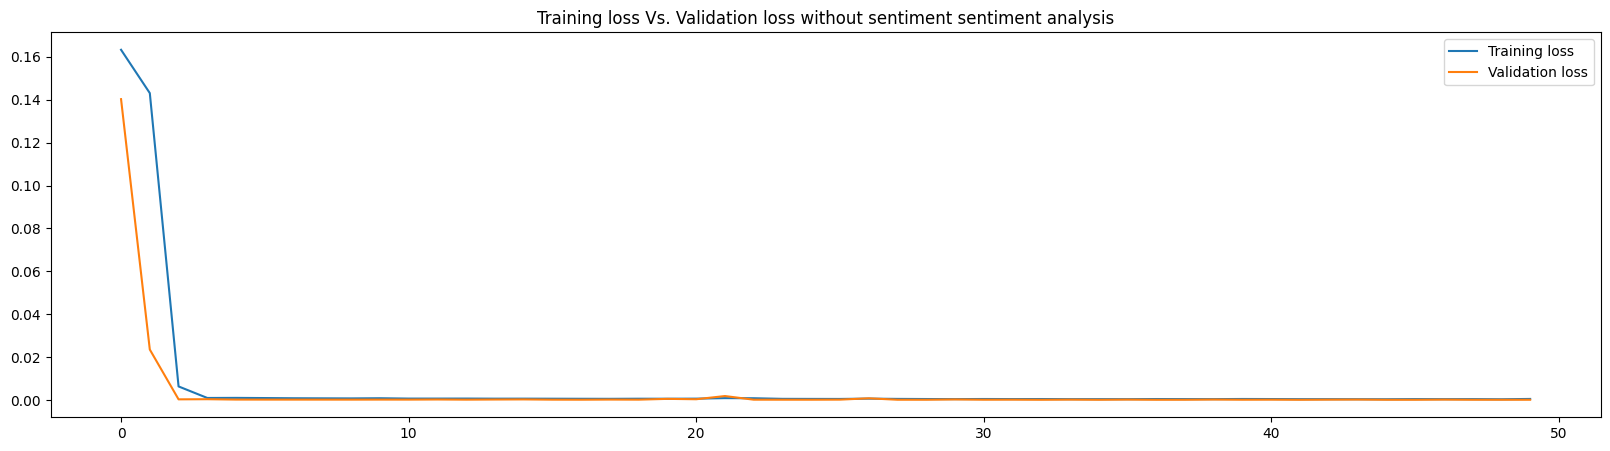

In [20]:
plt.figure(figsize=(20,5))
plt.plot(history_without_sentiment.history['loss'], label='Training loss')
plt.plot(history_without_sentiment.history['val_loss'], label='Validation loss')
plt.title('Training loss Vs. Validation loss without sentiment sentiment analysis')
plt.legend()

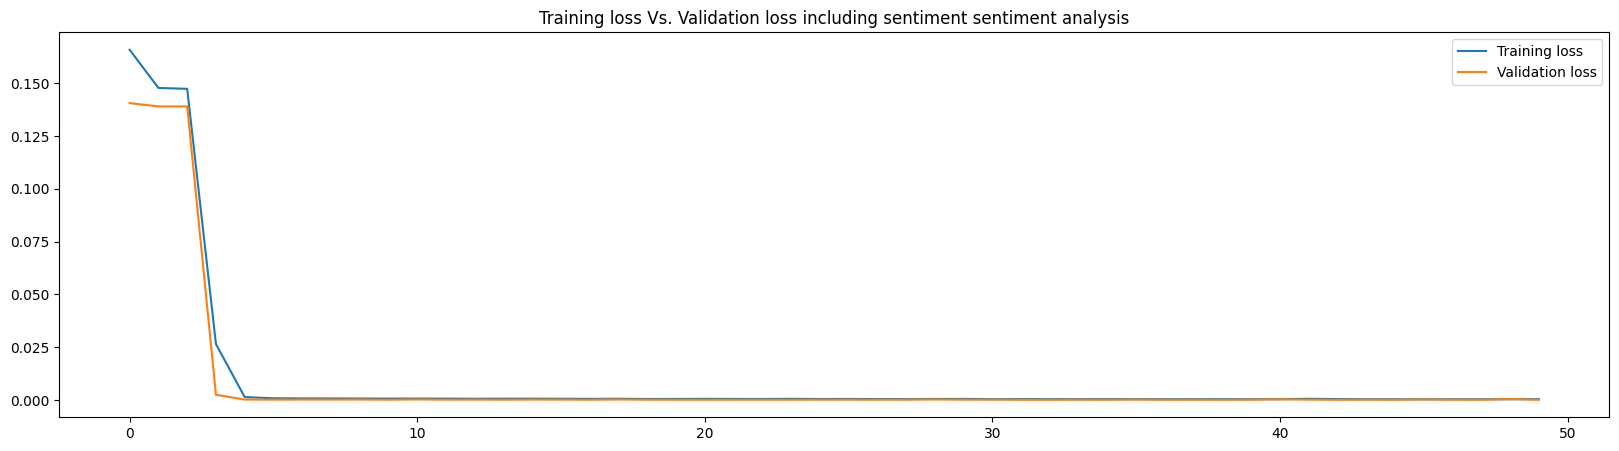

In [21]:
plt.figure(figsize=(20,5))
plt.plot(history_sentiment.history['loss'], label='Training loss')
plt.plot(history_sentiment.history['val_loss'], label='Validation loss')
plt.title('Training loss Vs. Validation loss including sentiment sentiment analysis')
plt.legend()

In [22]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
from math import sqrt

def plot_predictions_with_dates (type,sentiment,dates,y_actual_lstm,y_pred_lstm):
    predicted_features=['Open','Adj Close']
    for i,predicted_feature in enumerate(predicted_features):
        plt.figure(figsize=(15,6))
        if sentiment :
            plt.title(f'LSTM {type} prediction of {predicted_feature} feature After adding sentiment sentiment analysis')
        else:
            plt.title(f'LSTM {type} prediction of {predicted_feature} feature without sentiment sentiment analysis')
        sns.lineplot(x=dates, y=y_actual_lstm[:,i],label='Actual')
        sns.lineplot(x=dates, y=y_pred_lstm[:, i], label='Predicted')
        plt.show()
        error=mean_squared_error(y_actual_lstm[:,i], y_pred_lstm[:, i])
        print(f'Mean square error for {predicted_feature} ={error}')
    print('Total mean square error', mean_squared_error(y_actual_lstm, y_pred_lstm))

In [23]:
training_dates= df_for_training.index[:X_train_lstm_without_sentiment.shape[0]]
#Make prediction
training_prediction_without_sentiment = cnn_lstm_model_without_sentiment.predict(X_train_lstm_without_sentiment)

training_prediction_sentiment = cnn_lstm_model_sentiment.predict(X_train_lstm_sentiment)

training_prediction_without_sentiment=training_prediction_without_sentiment.reshape(training_prediction_without_sentiment.shape[0], training_prediction_without_sentiment.shape[2])

training_prediction_sentiment=training_prediction_sentiment.reshape(training_prediction_sentiment.shape[0], training_prediction_sentiment.shape[2])

y_train_pred_lstm_without_sentiment = scaler_for_inference.inverse_transform(training_prediction_without_sentiment)

y_train_pred_lstm_sentiment = scaler_for_inference.inverse_transform(training_prediction_sentiment)

y_train_lstm_reshaped_without_sentiment=y_train_lstm_without_sentiment.reshape(y_train_lstm_without_sentiment.shape[0], y_train_lstm_without_sentiment.shape[2])

y_train_actual_lstm = scaler_for_inference.inverse_transform(y_train_lstm_reshaped_without_sentiment)


66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


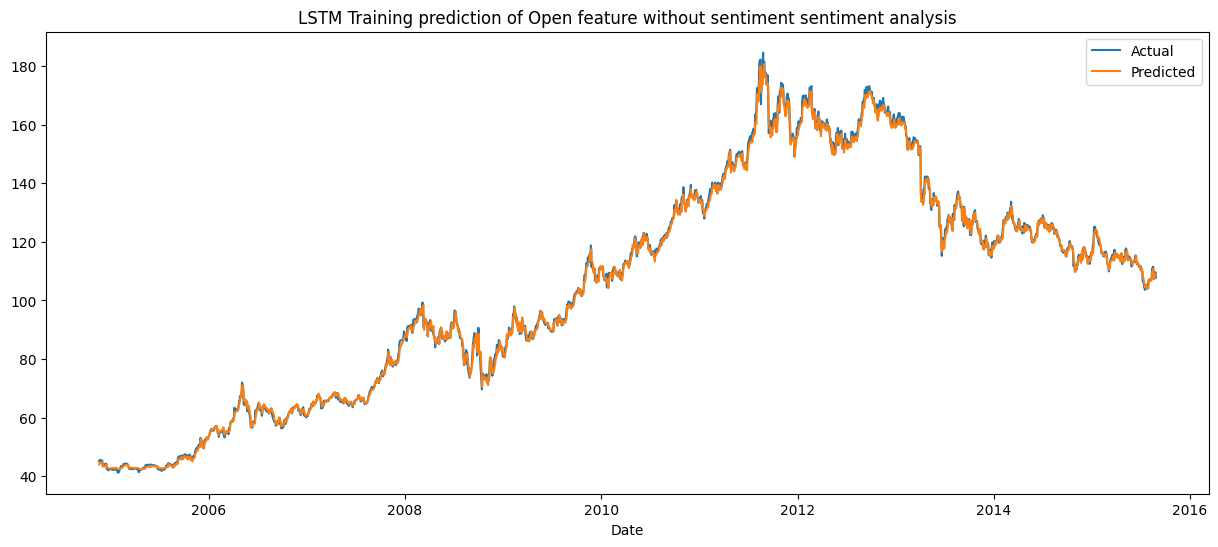

Mean square error for Open =2.2268208973703336


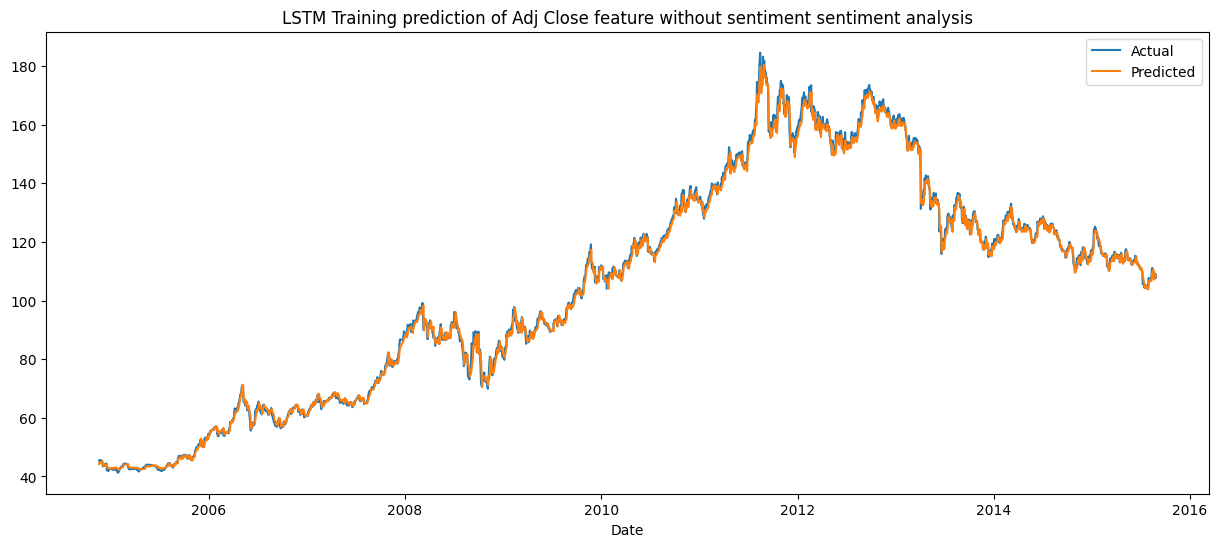

Mean square error for Adj Close =3.3928494518148447
Total mean square error 2.8098351745925885


In [24]:
plot_predictions_with_dates('Training',False,training_dates,y_train_actual_lstm,y_train_pred_lstm_without_sentiment)


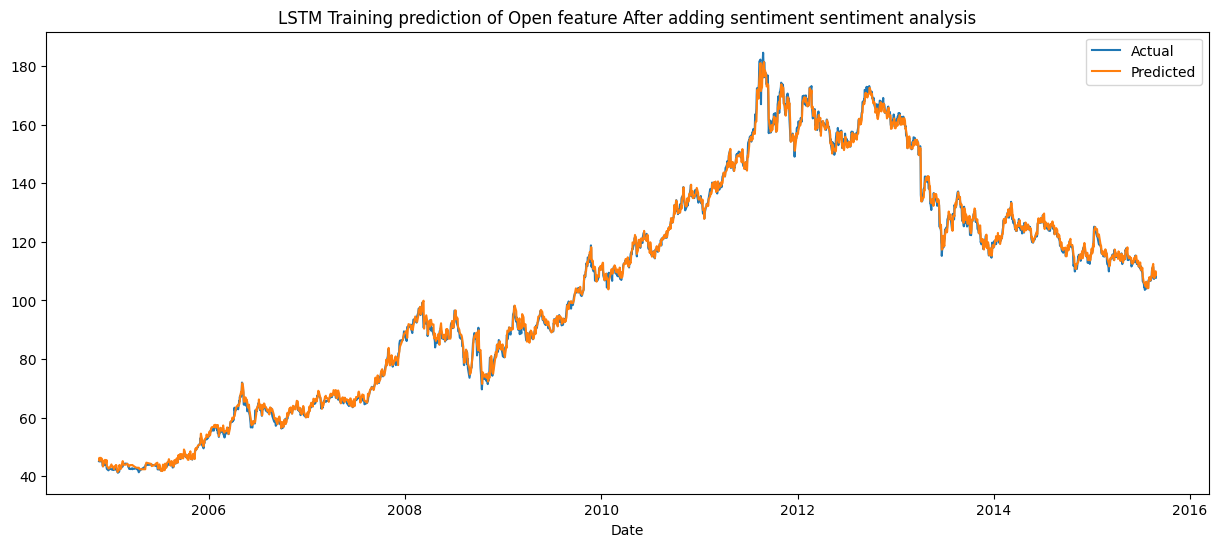

Mean square error for Open =2.220873056035477


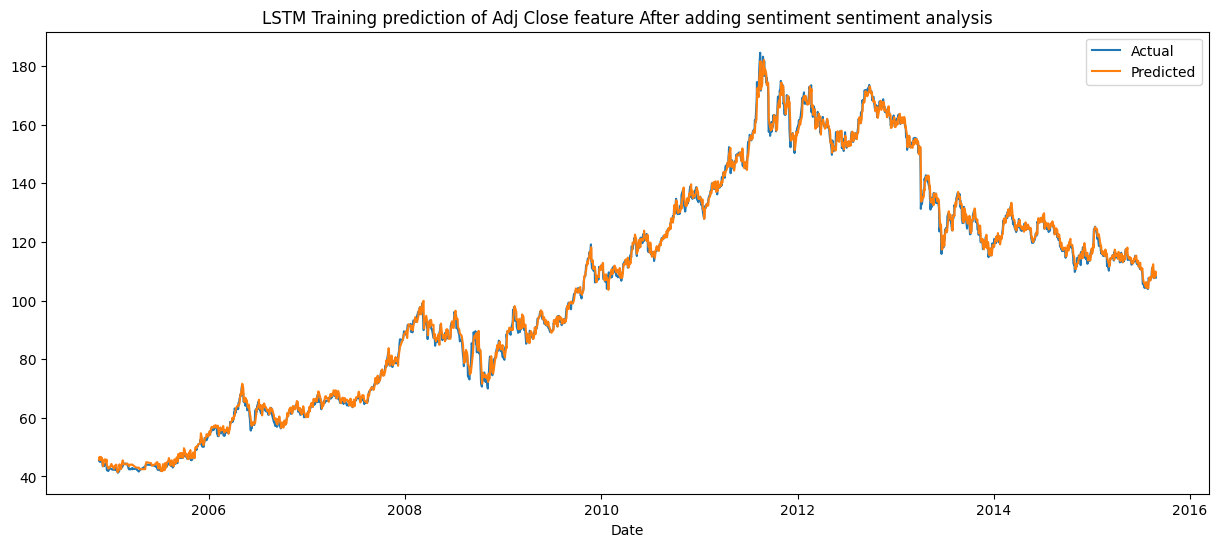

Mean square error for Adj Close =3.1438941790930253
Total mean square error 2.682383617564252


In [25]:
plot_predictions_with_dates('Training',True,training_dates,y_train_actual_lstm,y_train_pred_lstm_sentiment)

In [26]:
validation_dates= df_for_training.index[X_train_lstm_without_sentiment.shape[0]:X_train_lstm_without_sentiment.shape[0] + X_val_lstm_without_sentiment.shape[0]]
#Make prediction
validation_prediction_without_sentiment = cnn_lstm_model_without_sentiment.predict(X_val_lstm_without_sentiment)

validation_prediction_sentiment = cnn_lstm_model_sentiment.predict(X_val_lstm_sentiment)

validation_prediction_without_sentiment=validation_prediction_without_sentiment.reshape(validation_prediction_without_sentiment.shape[0], validation_prediction_without_sentiment.shape[2])


validation_prediction_sentiment=validation_prediction_sentiment.reshape(validation_prediction_sentiment.shape[0], validation_prediction_sentiment.shape[2])


y_val_pred_lstm_without_sentiment = scaler_for_inference.inverse_transform(validation_prediction_without_sentiment)
y_val_pred_lstm_sentiment = scaler_for_inference.inverse_transform(validation_prediction_sentiment)

y_val_actual_lstm_reshaped_without_sentiment=y_val_lstm_without_sentiment.reshape(y_val_lstm_without_sentiment.shape[0], y_val_lstm_without_sentiment.shape[2])

y_val_actual_lstm = scaler_for_inference.inverse_transform(y_val_actual_lstm_reshaped_without_sentiment)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


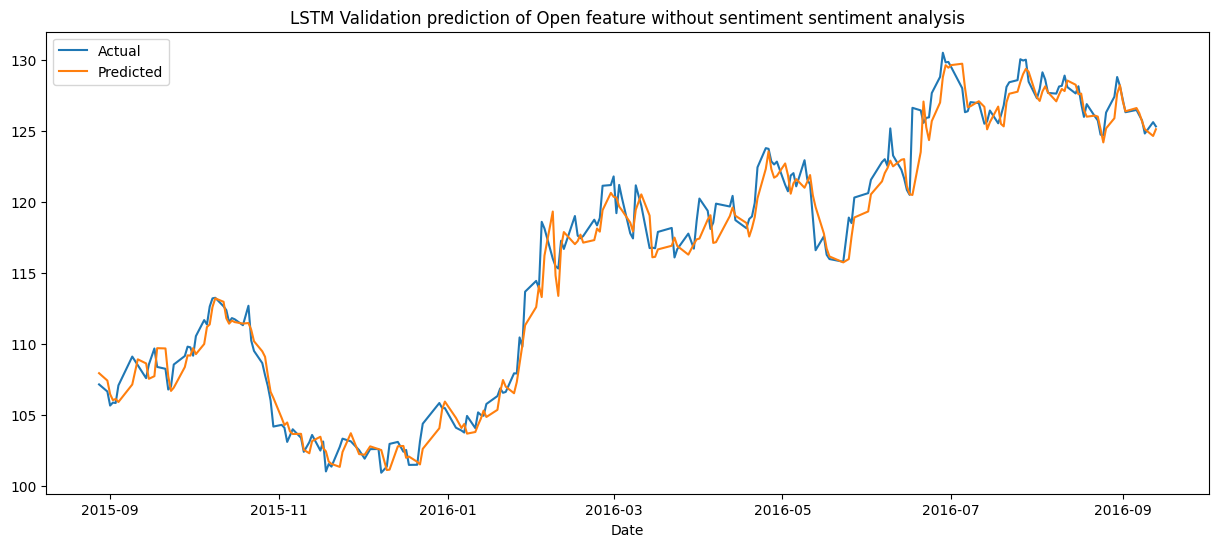

Mean square error for Open =1.4768456545928104


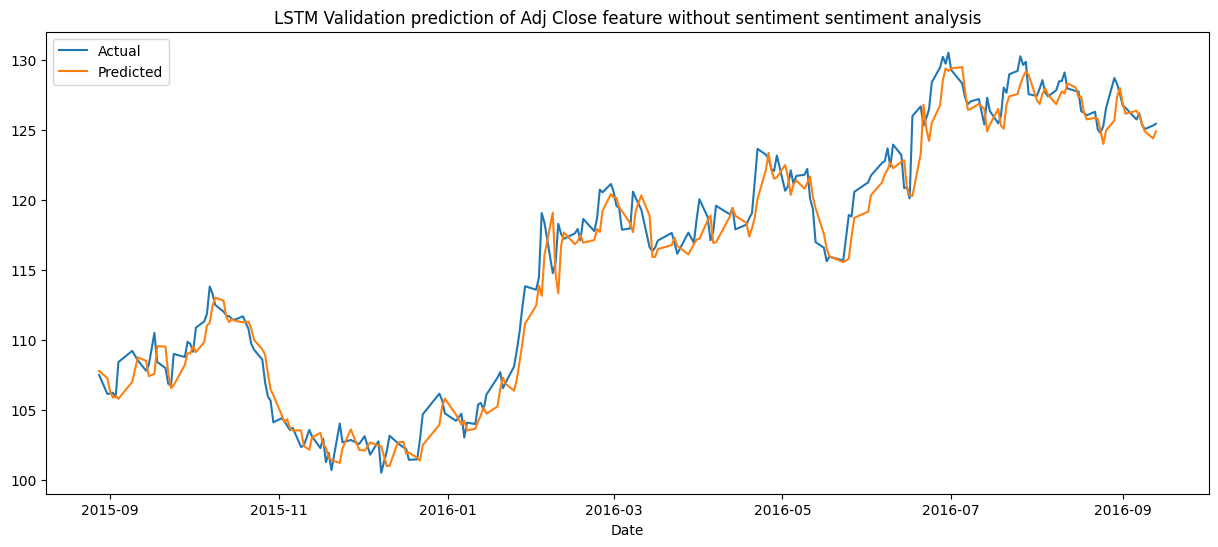

Mean square error for Adj Close =2.144830515626102
Total mean square error 1.8108380851094559


In [27]:
plot_predictions_with_dates('Validation',False,validation_dates,y_val_actual_lstm,y_val_pred_lstm_without_sentiment)


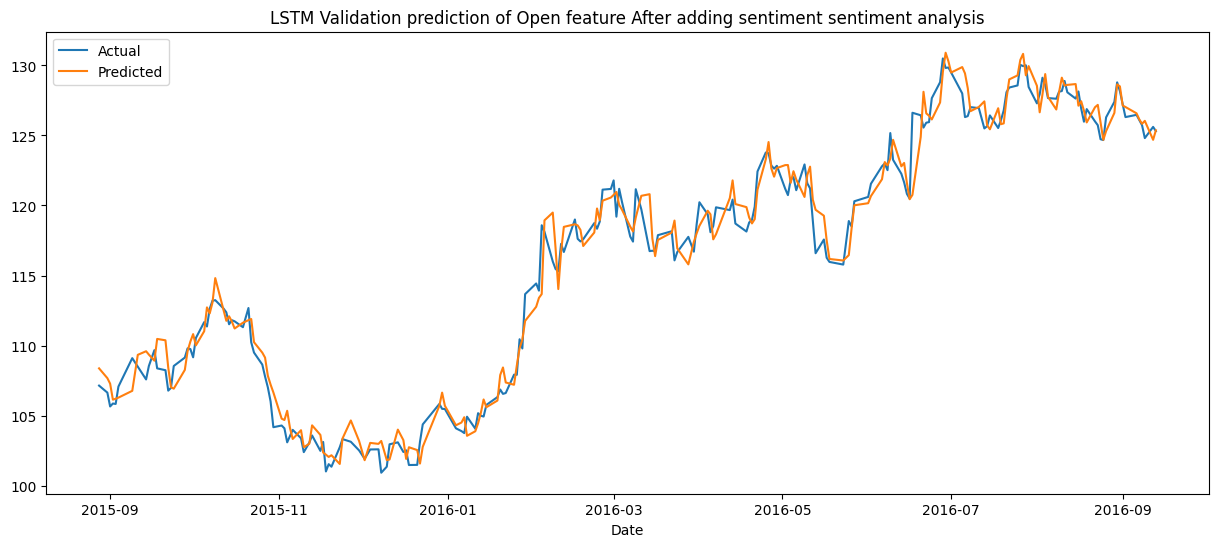

Mean square error for Open =1.5937926945128291


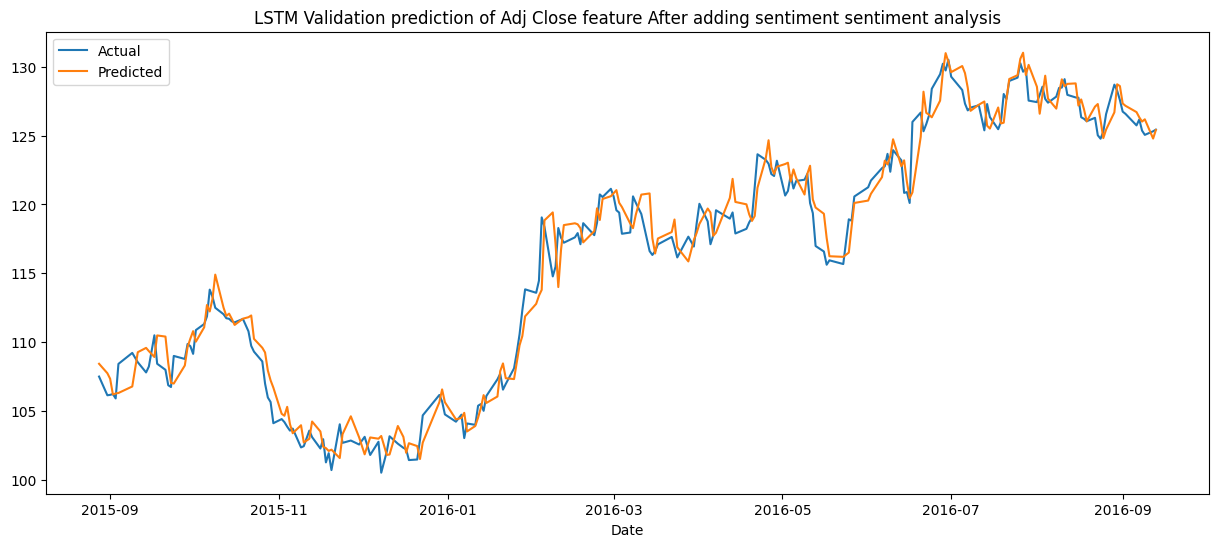

Mean square error for Adj Close =2.0815851982226743
Total mean square error 1.8376889463677517


In [28]:
plot_predictions_with_dates('Validation',True,validation_dates,y_val_actual_lstm,y_val_pred_lstm_sentiment)


In [29]:
testing_dates= df_for_training.index[-X_test_lstm_without_sentiment.shape[0]:]
#Make prediction
testing_prediction_without_sentiment = cnn_lstm_model_without_sentiment.predict(X_test_lstm_without_sentiment)
testing_prediction_sentiment = cnn_lstm_model_sentiment.predict(X_test_lstm_sentiment)

testing_prediction_without_sentiment=testing_prediction_without_sentiment.reshape(testing_prediction_without_sentiment.shape[0], testing_prediction_without_sentiment.shape[2])
testing_prediction_sentiment=testing_prediction_sentiment.reshape(testing_prediction_sentiment.shape[0], testing_prediction_sentiment.shape[2])

y_test_pred_lstm_without_sentiment = scaler_for_inference.inverse_transform(testing_prediction_without_sentiment)
y_test_pred_lstm_sentiment = scaler_for_inference.inverse_transform(testing_prediction_sentiment)

y_test_actual_lstm_reshaped_without_sentiment=y_test_lstm_without_sentiment.reshape(y_test_lstm_without_sentiment.shape[0], y_test_lstm_without_sentiment.shape[2])


y_test_actual_lstm = scaler_for_inference.inverse_transform(y_test_actual_lstm_reshaped_without_sentiment)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


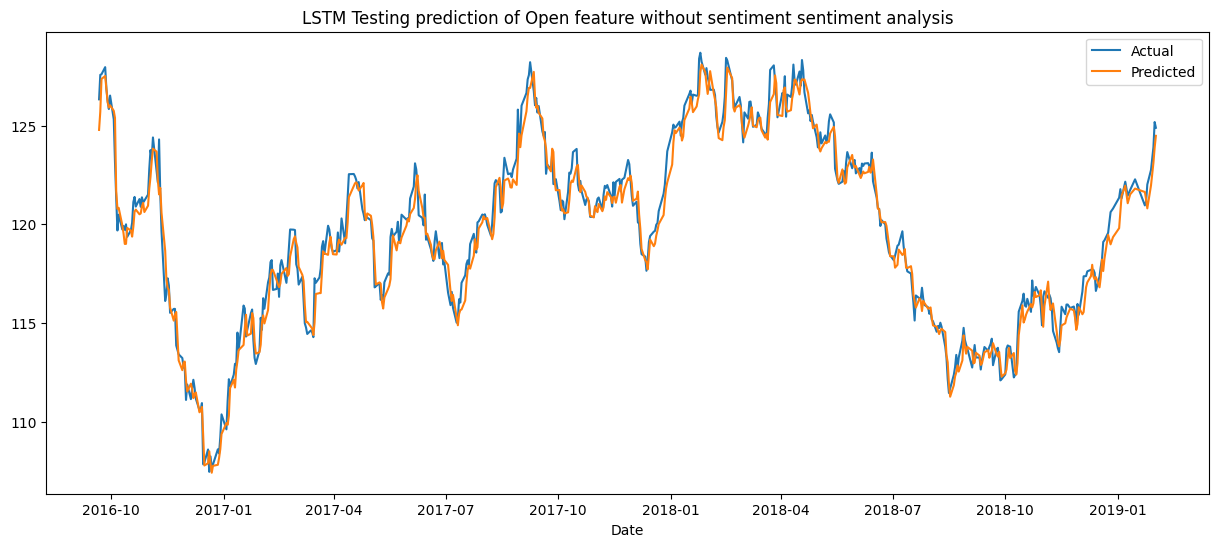

Mean square error for Open =0.5791546427353296


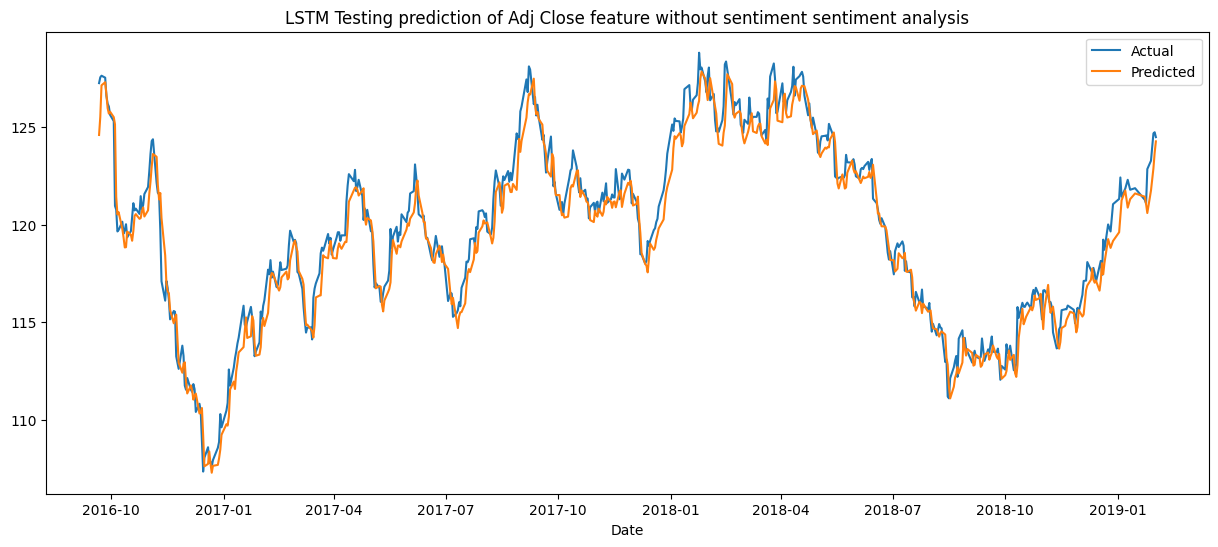

Mean square error for Adj Close =0.9300927010511202
Total mean square error 0.7546236718932244


In [30]:
plot_predictions_with_dates('Testing',False,testing_dates,y_test_actual_lstm,y_test_pred_lstm_without_sentiment)


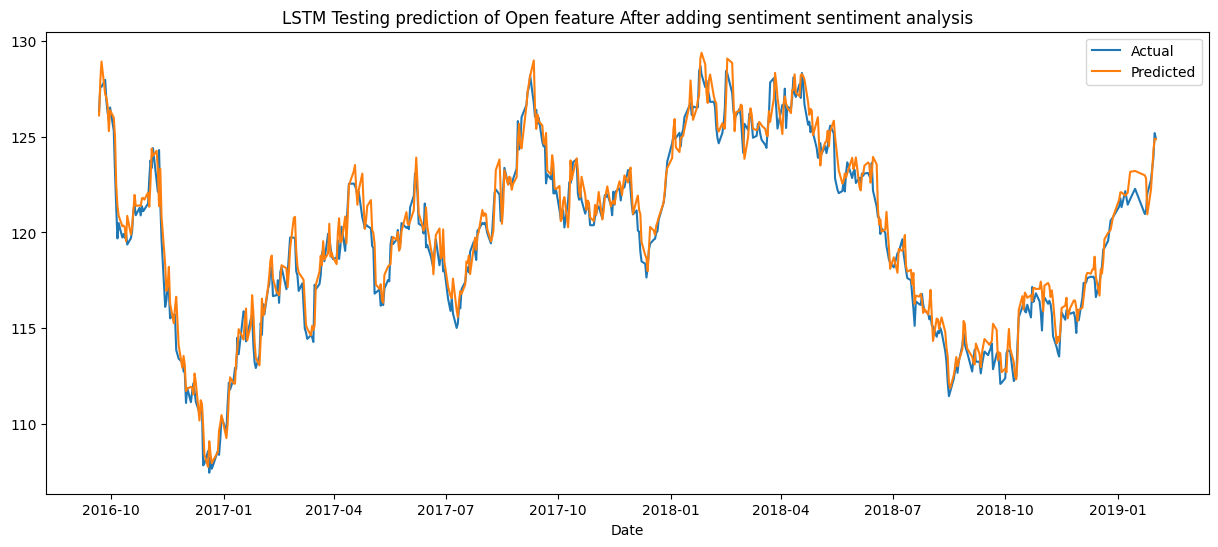

Mean square error for Open =0.7301387592045243


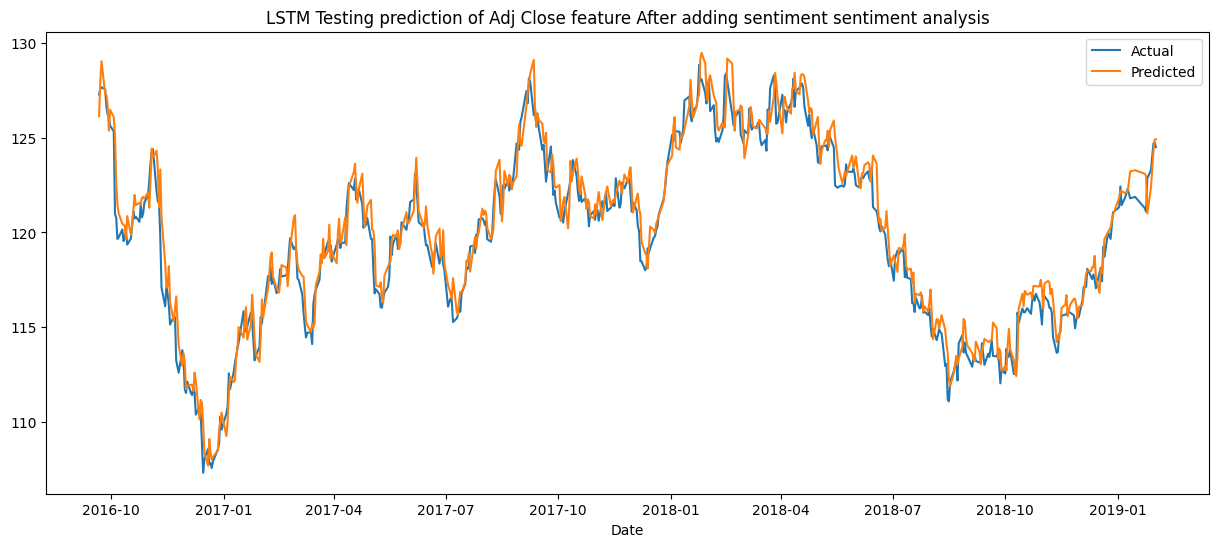

Mean square error for Adj Close =1.049478780092651
Total mean square error 0.8898087696485878


In [31]:
plot_predictions_with_dates('Testing',True,testing_dates,y_test_actual_lstm,y_test_pred_lstm_sentiment)
